<a href="https://colab.research.google.com/github/Bobi-Jordanov/H4H-MIR-project/blob/main/Breast_Cancer_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Importing the libraries the will be used in this project


In [ ]:
import numpy as np                # library used for linear algebra and better manipulation of numpy arrays
import pandas as pd               # library used for better manipulation of large data sets
import matplotlib.pyplot as plt   # library used for simple plotting
import seaborn as sns             # library used for generating advaced plots

#Using Linear regression

In [ ]:
# Importing the needed libraries for using Linear regression
from sklearn.linear_model import LogisticRegression   # module for using Logistic Regression
from sklearn.model_selection import train_test_split  # module for splitting the original data into test and training data
from sklearn.metrics import accuracy_score            # module being used for model evaluation, or more precisely checking the accuracy of the prediction of the model

#Reading the data set

In [ ]:
data_set = pd.read_csv('data.csv')        # Reading the main .csv data file, and setting it to a variable named data_set
data_set.shape                            # showcasing the dimensions of the data
data_set.head                             # showcasing the first 5 rows of the data
data_set                                  # prining out the data

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,NaN
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,NaN
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,NaN
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,NaN


In [ ]:
#Setting M->0 and B->1, because we can't work with string values
mapping = {
    'M' : 0,
    'B' : 1
}

data_set = data_set.replace({'diagnosis': mapping}) # replacing the string values of M and B with 0 and 1, respectively
data_set

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,0,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,0,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,0,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,0,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,0,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,NaN
565,926682,0,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,NaN
566,926954,0,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,NaN
567,927241,0,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,NaN


In [ ]:
# Number of rows and columns
data_set.shape

(569, 33)

In [ ]:
# Information about the data
data_set.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    int64  
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

#Dropping and Separating the data

In [ ]:
# Dropping the columns: Unnamed: 32 - because it's a zero value, id - because it's not needed,
# and diagnosis - so that it can be put in a separate variable Y_data, and treated as the ouput
dropped_list=['Unnamed: 32','id', 'diagnosis']
Y_data=data_set.diagnosis                       # output
X_data=data_set.drop(dropped_list, axis=1)      # input
X_data.info()                                 # info about the type and count of the fetures

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   radius_mean              569 non-null    float64
 1   texture_mean             569 non-null    float64
 2   perimeter_mean           569 non-null    float64
 3   area_mean                569 non-null    float64
 4   smoothness_mean          569 non-null    float64
 5   compactness_mean         569 non-null    float64
 6   concavity_mean           569 non-null    float64
 7   concave points_mean      569 non-null    float64
 8   symmetry_mean            569 non-null    float64
 9   fractal_dimension_mean   569 non-null    float64
 10  radius_se                569 non-null    float64
 11  texture_se               569 non-null    float64
 12  perimeter_se             569 non-null    float64
 13  area_se                  569 non-null    float64
 14  smoothness_se            5

In [ ]:
# Checking if there are missing values, after dropping some columns
data_set.isnull().sum

<bound method NDFrame._add_numeric_operations.<locals>.sum of         id  diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    False      False        False         False           False      False   
1    False      False        False         False           False      False   
2    False      False        False         False           False      False   
3    False      False        False         False           False      False   
4    False      False        False         False           False      False   
..     ...        ...          ...           ...             ...        ...   
564  False      False        False         False           False      False   
565  False      False        False         False           False      False   
566  False      False        False         False           False      False   
567  False      False        False         False           False      False   
568  False      False        False         False           False     

#Plotting/Visualisation

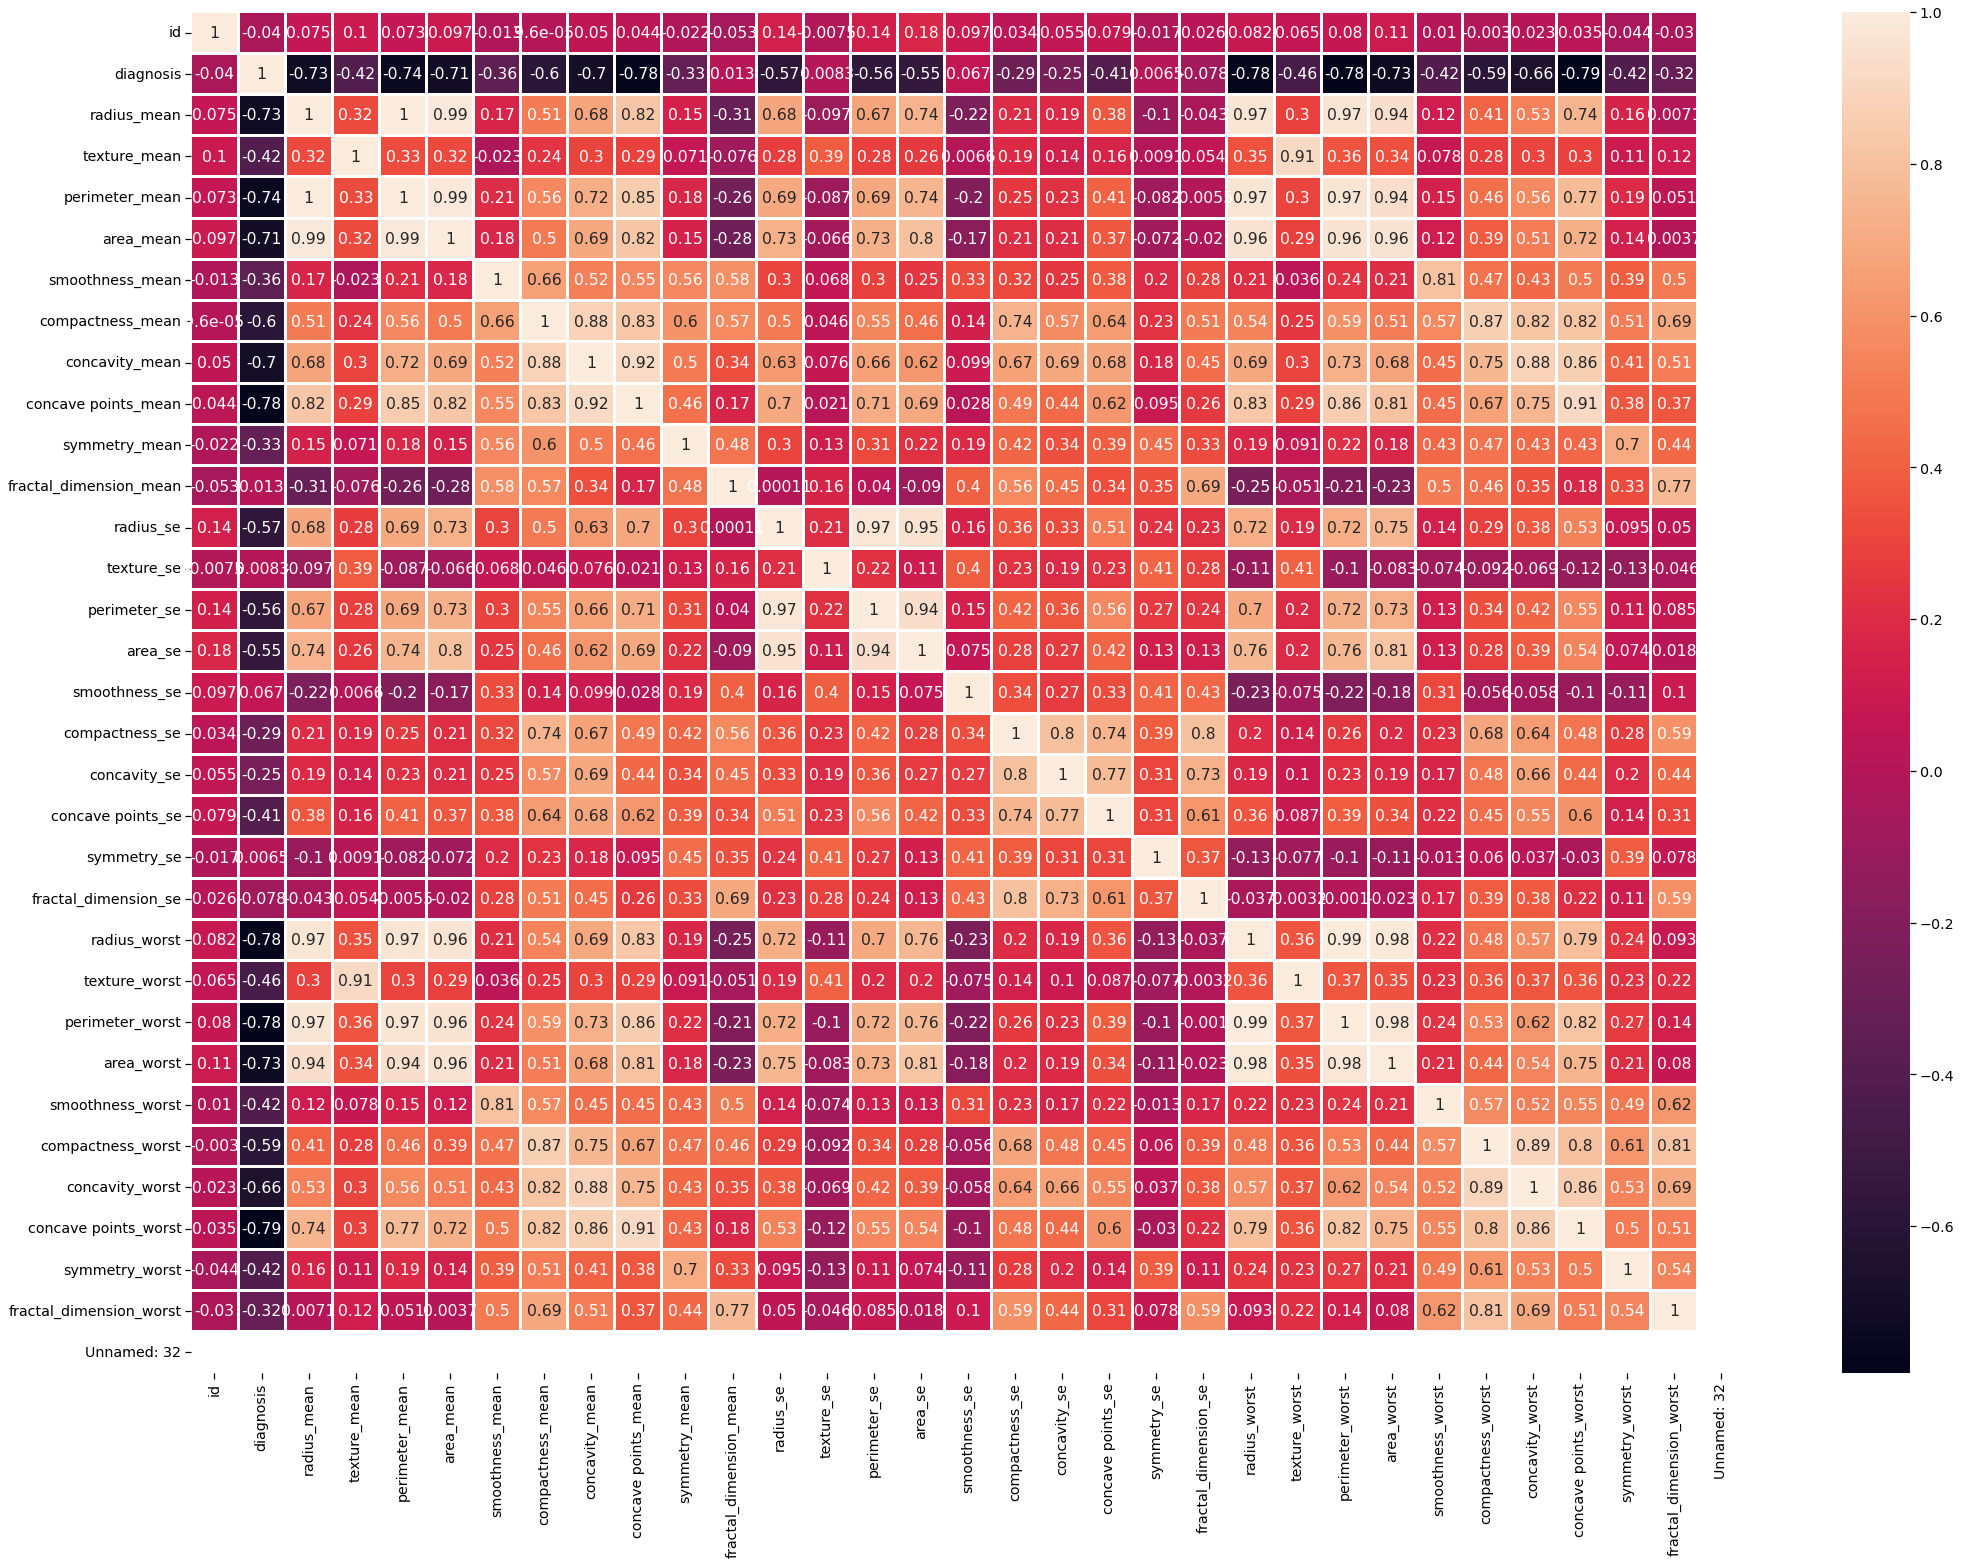

In [ ]:
# Correlation matrix - Visualisation of the features and their correlation
plt.figure(figsize=(30,22))
sns.set_context('notebook',font_scale = 1.3)
sns.heatmap(data_set.corr(),annot=True,linewidth =2)
plt.tight_layout()

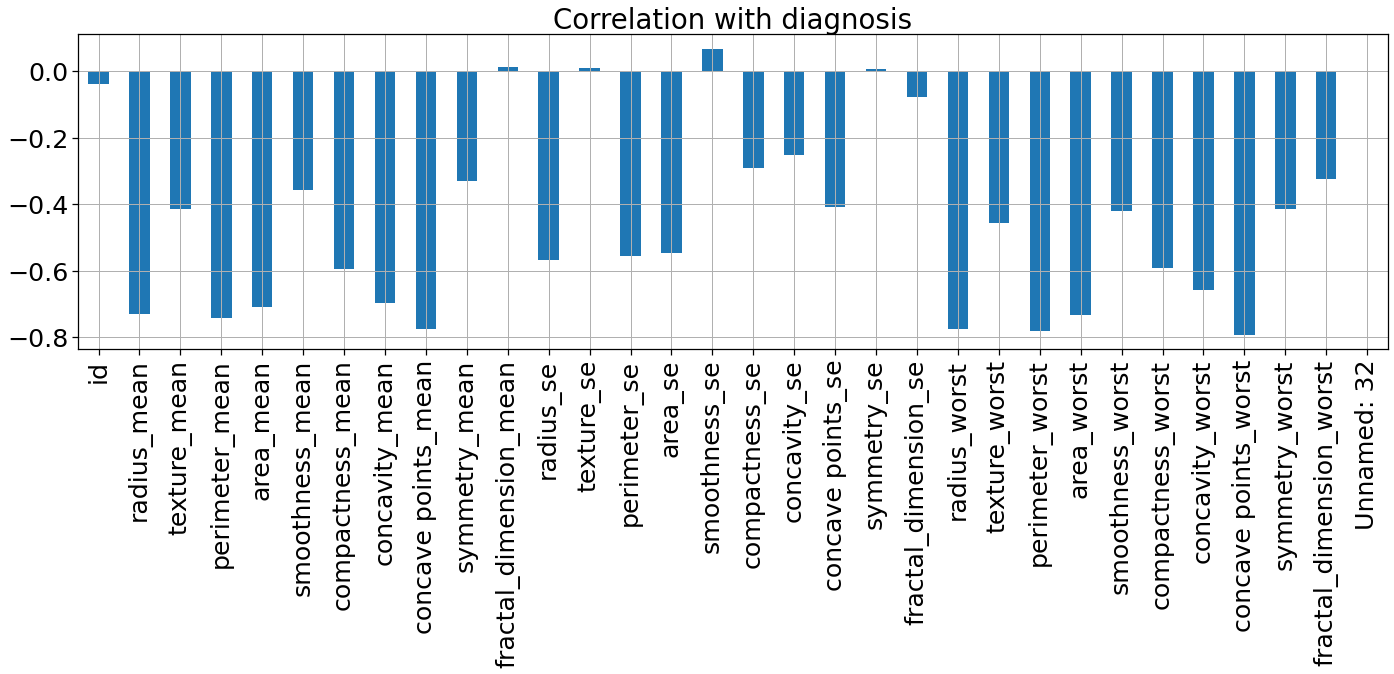

In [ ]:
# With this we can see which of the features are positivly and negtivly correlated with the output (diagnosis)
sns.set_context('notebook',font_scale = 2.3)
data_set.drop('diagnosis', axis=1).corrwith(data_set.diagnosis).plot(kind='bar', grid=True, figsize=(20,10),
                                                        title="Correlation with diagnosis")
plt.tight_layout()

Number of Benign:  357
Number of Malignant :  212


/usr/local/lib/python3.7/dist-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


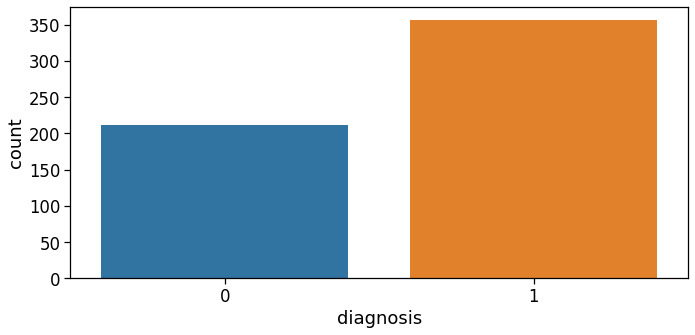

In [ ]:
# Plotting the amount of malignant and benign cases
plt.figure(figsize=(10,5))
sns.set_context('notebook',font_scale = 1.5)
sns.countplot(Y_data, label='Count')
B, M = Y_data.value_counts()
plt.tight_layout()

# Printing out the distribution of the target variable
print('Number of Benign: ',B)
print('Number of Malignant : ',M)

In [ ]:
# Showcasing some statistical measures about the data set
X_data.describe()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


#Violin plot, to show the distribution around the median

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]),
 <a list of 10 Text major ticklabel objects>)

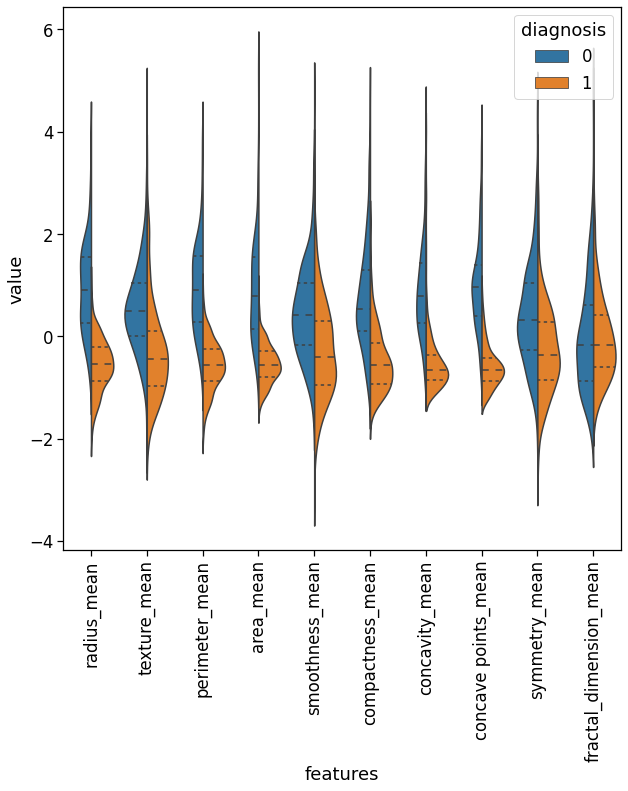

In [ ]:
# Before using the violin plot we need to normalize and standardize the data set
# because the differences between the values of the features are very high for observing

# First ten features
data_diagnosis = Y_data
data = X_data
data_n_2 = (data - data.mean()) / (data.std())  # standardization
data = pd.concat([Y_data, data_n_2.iloc[:,0:10]], axis=1) # separating the first ten features
data = pd.melt(data, id_vars="diagnosis", var_name="features", value_name='value')
plt.figure(figsize=(10,10))
sns.violinplot(x="features", y="value", hue="diagnosis", data=data,split=True, inner="quart")
plt.xticks(rotation=90)

**Conclusion from the above plot**

  - Some variables show a clear separation of the median between the Malignant and Bening, so they might be good while using clasification ex. texture_mean. There are, also, others that don't show a clear separation of the median between Malignant and Bening, ex. smoothness_mean, symmetry_mean and fractal_dimension_mean

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]),
 <a list of 10 Text major ticklabel objects>)

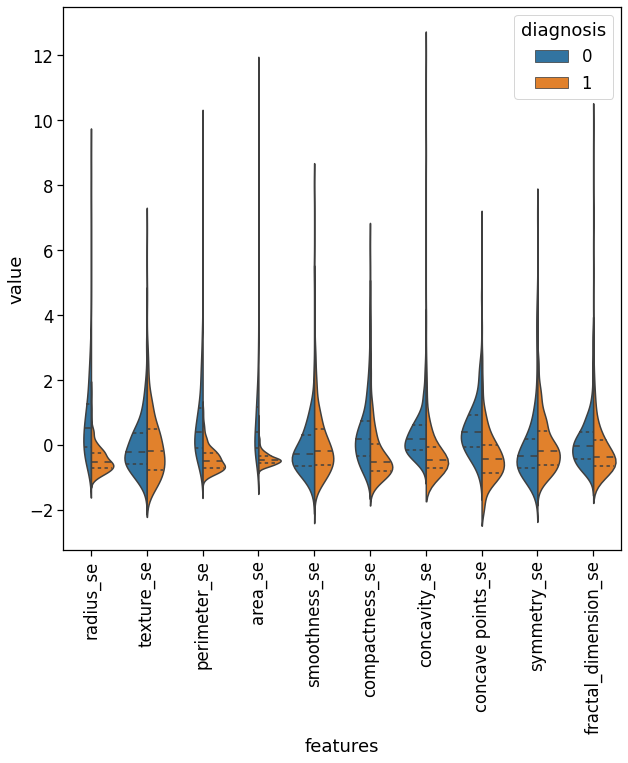

In [ ]:
# Second ten features
data_diagnosis = Y_data
data = X_data
data_n_2 = (data - data.mean()) / (data.std()) # standardization
data = pd.concat([Y_data, data_n_2.iloc[:,10:20]], axis=1) # separating the second ten features
data = pd.melt(data, id_vars="diagnosis", var_name="features", value_name='value')
plt.figure(figsize=(10,10))
sns.violinplot(x="features", y="value", hue="diagnosis", data=data,split=True, inner="quart")
plt.xticks(rotation=90)

**Conclusion from the above plot**

  - Some variables show a clear separation of the median between the Malignant and Bening, so they might be good while using clasification ex. comapctness_se and concave points_se. And, the rest of the fetures don't show a clear separation of the median between Malignant and Benign.

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]),
 <a list of 10 Text major ticklabel objects>)

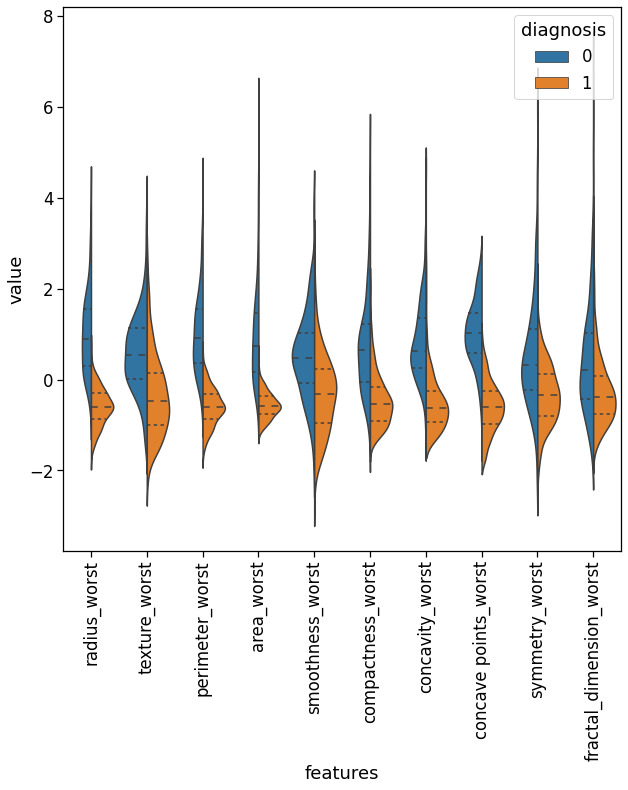

In [ ]:
# Last ten features
data_diagnosis = Y_data
data = X_data
data_n_2 = (data - data.mean()) / (data.std()) # standardization
data = pd.concat([Y_data, data_n_2.iloc[:,20:30]], axis=1) # separating the last ten features
data = pd.melt(data, id_vars="diagnosis", var_name="features", value_name='value')
plt.figure(figsize=(10,10))
sns.violinplot(x="features", y="value", hue="diagnosis", data=data,split=True, inner="quart")
plt.xticks(rotation=90)

**Conclusion from the above plot**

  - The features, concavity_worst and concave point_worst look very similar, so we might be able to drop them

#Swarm plot, to better see the variance of the features

/usr/local/lib/python3.7/dist-packages/seaborn/categorical.py:1296: UserWarning: 41.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.7/dist-packages/seaborn/categorical.py:1296: UserWarning: 41.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.7/dist-packages/seaborn/categorical.py:1296: UserWarning: 41.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.7/dist-packages/seaborn/categorical.py:1296: UserWarning: 46.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.7/dist-packages/seaborn/categorical.py:1296: UserWarning: 39.7% of the points cannot be placed; y

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]),
 <a list of 10 Text major ticklabel objects>)

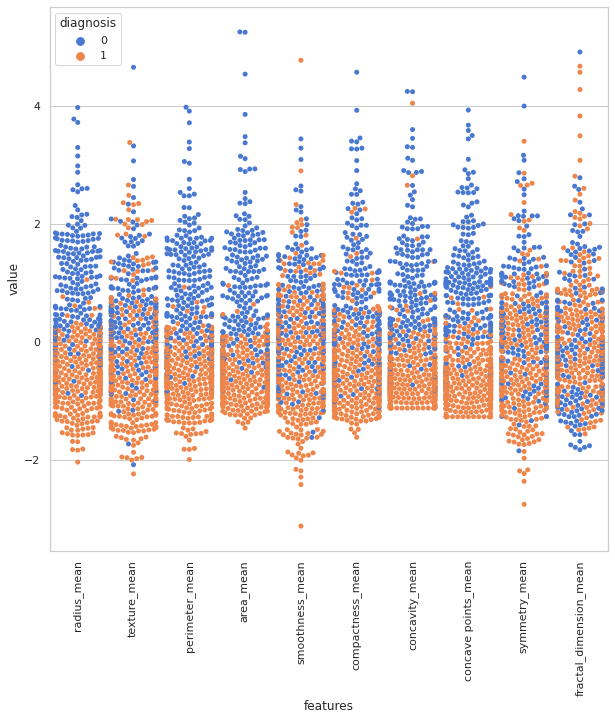

In [ ]:
import time

#First ten features
sns.set(style="whitegrid", palette="muted")
data_dia = Y_data
data = X_data
data_n_2 = (data - data.mean()) / (data.std()) # standardization
data = pd.concat([Y_data, data_n_2.iloc[:,:10]], axis=1) # separating the first ten features
data = pd.melt(data,id_vars="diagnosis", var_name="features", value_name='value')
plt.figure(figsize=(10,10))
tic = time.time()
sns.swarmplot(x="features", y="value", hue="diagnosis", data=data)

plt.xticks(rotation=90)

**Conclusion from the above plot**

  - Some features can be easily separated into Benign and Malignant, like radius_mean, diameter_mean, area_mean, concativity_mean and concave points_mean, while the rest of the features can't be, for instance texture_mean

/usr/local/lib/python3.7/dist-packages/seaborn/categorical.py:1296: UserWarning: 41.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.7/dist-packages/seaborn/categorical.py:1296: UserWarning: 41.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.7/dist-packages/seaborn/categorical.py:1296: UserWarning: 41.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.7/dist-packages/seaborn/categorical.py:1296: UserWarning: 46.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.7/dist-packages/seaborn/categorical.py:1296: UserWarning: 39.7% of the points cannot be placed; y

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]),
 <a list of 10 Text major ticklabel objects>)

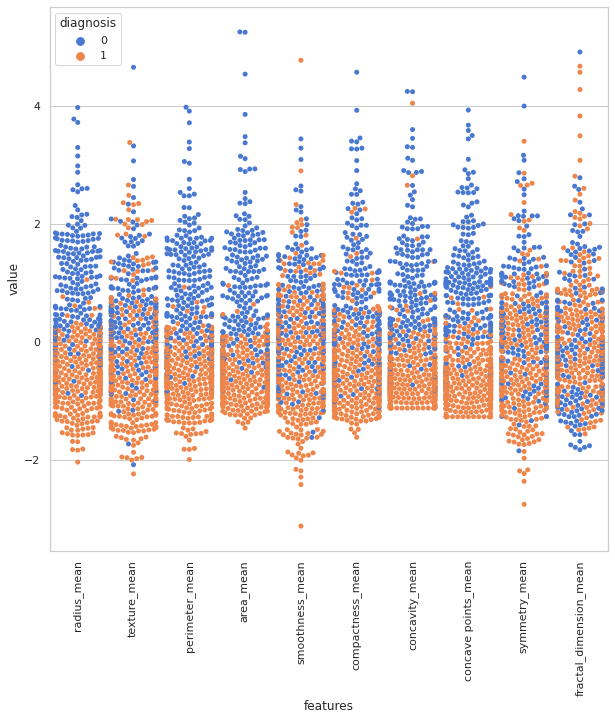

In [ ]:
#Second ten features
sns.set(style="whitegrid", palette="muted")
data_dia = Y_data
data = X_data
data_n_2 = (data - data.mean()) / (data.std()) # standardization
data = pd.concat([Y_data, data_n_2.iloc[:,:10]], axis=1) # separating the second ten features
data = pd.melt(data,id_vars="diagnosis", var_name="features", value_name='value')
plt.figure(figsize=(10,10))
tic = time.time()
sns.swarmplot(x="features", y="value", hue="diagnosis", data=data)

plt.xticks(rotation=90)

/usr/local/lib/python3.7/dist-packages/seaborn/categorical.py:1296: UserWarning: 41.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.7/dist-packages/seaborn/categorical.py:1296: UserWarning: 41.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.7/dist-packages/seaborn/categorical.py:1296: UserWarning: 41.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.7/dist-packages/seaborn/categorical.py:1296: UserWarning: 46.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.7/dist-packages/seaborn/categorical.py:1296: UserWarning: 39.7% of the points cannot be placed; y

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]),
 <a list of 10 Text major ticklabel objects>)

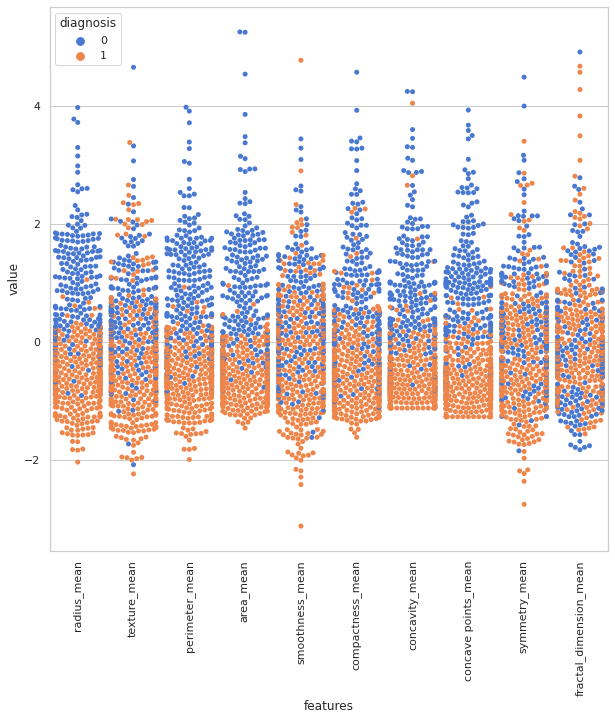

In [ ]:
#Last ten features
sns.set(style="whitegrid", palette="muted")
data_dia = Y_data
data = X_data
data_n_2 = (data - data.mean()) / (data.std()) # standardization
data = pd.concat([Y_data, data_n_2.iloc[:,:10]], axis=1) # separating the last ten features
data = pd.melt(data,id_vars="diagnosis", var_name="features", value_name='value')
plt.figure(figsize=(10,10))
tic = time.time()
sns.swarmplot(x="features", y="value", hue="diagnosis", data=data)

plt.xticks(rotation=90)

In [ ]:
data_set.groupby('diagnosis').mean() #the values of the M are larger than B

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
diagnosis,,,,,,,,,,,,,,,,,,,,,
0,3.681805e+07,17.462830,21.604906,115.365377,978.376415,0.102898,0.145188,0.160775,0.087990,0.192909,...,29.318208,141.370330,1422.286321,0.144845,0.374824,0.450606,0.182237,0.323468,0.091530,NaN
1,2.654382e+07,12.146524,17.914762,78.075406,462.790196,0.092478,0.080085,0.046058,0.025717,0.174186,...,23.515070,87.005938,558.899440,0.124959,0.182673,0.166238,0.074444,0.270246,0.079442,NaN


#Splitting the data

In [ ]:
# Splitting the data into traning and testing data
X_train, X_test, Y_train, Y_test=train_test_split(X_data, Y_data, test_size=0.25, random_state=2)
print(X_data.shape, X_train.shape, X_test.shape)

(569, 30) (426, 30) (143, 30)


#Feature scaling

In [ ]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

#Model Training

In [ ]:
# Model training
model=LogisticRegression()

# Traning the Linear Regrression model using traning data
model.fit(X_train,Y_train)  # it's trying to find a realtion between the x and y values

LogisticRegression()

#Model Evaluation - Train/Test Accuracy

In [ ]:
# Checking the accuracy on traning data
X_train_prediction=model.predict(X_train) #predicting wether the label is going to be 0 or 1, based on the model
training_data_accuracy=accuracy_score(Y_train, X_train_prediction)

# Printing out the accuracy on the train data
print('Accuracy training data = ', training_data_accuracy)

Accuracy training data =  0.9859154929577465


In [ ]:
# Checking the accuracy on the test data
X_test_prediction=model.predict(X_test) #predicting whether the label is going to be 0 or 1, based on the model
test_data_accuracy=accuracy_score(Y_test, X_test_prediction)

# Printing out the accuracy on the test data
print('Accuracy on test data = ', test_data_accuracy)

Accuracy on test data =  0.972027972027972


#Building a predictive system fo Linear Regression




In [ ]:
input_data=(18.25,19.98,119.6,1040,0.09463,0.109,0.1127,0.074,0.1794,0.05742,0.4467,0.7732,3.18,53.91,0.004314,0.01382,0.02254,0.01039,0.01369,0.002179,22.88,27.66,153.2,1606,0.1442,0.2576,0.3784,0.1932,0.3063,0.08368) #M
#input_data=(13.54,14.36,87.46,566.3,0.09779,0.08129,0.06664,0.04781,0.1885,0.05766,0.2699,0.7886,2.058,23.56,0.008462,0.0146,0.02387,0.01315,0.0198,0.0023,15.11,19.26,99.7,711.2,0.144,0.1773,0.239,0.1288,0.2977,0.07259) #B

# Change the input data to a numpy array
input_data_as_numpy_array=np.asarray(input_data)

# Reshape the numpy array as we are predicting for one data point
# beacuse the model doesn't know that we'd like to predict the value of only one feature
input_data_reshaped=input_data_as_numpy_array.reshape(1,-1)

prediction=model.predict(input_data_reshaped)
print(prediction)

# Checking if the value of the first element of the prediction list is 0 or 1
# And based on that we are writing out if the cancer is Malignant or Benign
if(prediction[0]==0):
  print('The breast cancer is Malignant')
else:
  print('The breast cancer is Bening')

[0]
The breast cancer is Malignant


#Using Decision Trees

In [ ]:
# Importing the needed libraries for using decision trees
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree

#Creating the Decision Tree and evaluating predictions

In [ ]:
#Creating the Decision tree
dec_tree = DecisionTreeClassifier(max_depth=3)
dec_tree = dec_tree.fit(X_train,Y_train)

#Predictions
X_test_pred=dec_tree.predict(X_test) #prediction based on the test data
X_train_pred=dec_tree.predict(X_train) #prediction based on the train data

#Checking the accuracy

In [ ]:
test_data_dec_tree=dec_tree.score(X_test,Y_test)
print('Accuracy test data = ', test_data_dec_tree)


Accuracy test data =  0.9230769230769231


In [ ]:
train_data_dec_tree=dec_tree.score(X_train, Y_train)
print('Accuracy training data = ', train_data_dec_tree)

Accuracy training data =  0.971830985915493


#Printing out the original and the predicited values

In [ ]:
breast_data_pred=dec_tree.predict(X_test)
breast_data_original=data_set.diagnosis

In [ ]:
# The predicted values
breastDataPred=[]
for i in range(len(breast_data_pred)):
  breastDataPred.append(breast_data_pred[i])

# The original values
breastDataOriginal=[]
for i in range(len(breast_data_original)):
  breastDataOriginal.append(breast_data_original[i])


print(breastDataPred)

[1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1]


#Building a predictave model for Decision Trees

In [ ]:
#input_data=(18.25,19.98,119.6,1040,0.09463,0.109,0.1127,0.074,0.1794,0.05742,0.4467,0.7732,3.18,53.91,0.004314,0.01382,0.02254,0.01039,0.01369,0.002179,22.88,27.66,153.2,1606,0.1442,0.2576,0.3784,0.1932,0.3063,0.08368) #M
input_data=(13.54,14.36,87.46,566.3,0.09779,0.08129,0.06664,0.04781,0.1885,0.05766,0.2699,0.7886,2.058,23.56,0.008462,0.0146,0.02387,0.01315,0.0198,0.0023,15.11,19.26,99.7,711.2,0.144,0.1773,0.239,0.1288,0.2977,0.07259) #B

# Change the input data to a numpy array
input_data_as_numpy_array=np.asarray(input_data)

# Reshape the numpy array as we are predicting for one data point
# beacuse the model doesn't know that we'd like to predict the value of only one feature
input_data_reshaped=input_data_as_numpy_array.reshape(1,-1)

prediction=dec_tree.predict(input_data_reshaped)
print(prediction)

# Checking if the value of the first element of the prediction list is 0 or 1
# And based on that we are writing out if the cancer is Malignant or Benign
if(prediction[0]==0):
  print('The breast cancer is Malignant')
else:
  print('The breast cancer is Bening')

[0]
The breast cancer is Malignant


#Checking the accuracy as a function of the depth of the tree

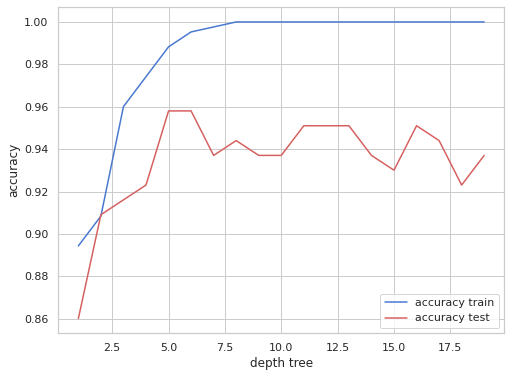

In [ ]:
nums=np.arange(1,20)
accuracy_test=[]
accuracy_train=[]

# The whole previous algorithm is being repeated where only the number of used trees is being changed
for num in nums:
  dec_tree = DecisionTreeClassifier(max_depth=num)
  dec_tree = dec_tree.fit(X_train,Y_train)

  accuracy_test.append(dec_tree.score(X_test, Y_test))
  accuracy_train.append(dec_tree.score(X_train, Y_train))

fig = plt.figure(figsize=(8, 6))
plt.ylabel('accuracy')
plt.xlabel('depth tree')
plt.plot(nums, accuracy_train,"-b", label="accuracy train")
plt.plot(nums, accuracy_test,"-r", label="accuracy test")
plt.legend(loc="best")
plt.show()

#Graphing the given tree

[Text(0.6907894736842105, 0.9285714285714286, 'X[22] <= -0.011\ngini = 0.464\nsamples = 426\nvalue = [156, 270]'),
 Text(0.4868421052631579, 0.7857142857142857, 'X[27] <= 0.693\ngini = 0.087\nsamples = 264\nvalue = [12, 252]'),
 Text(0.34210526315789475, 0.6428571428571429, 'X[27] <= 0.335\ngini = 0.038\nsamples = 255\nvalue = [5, 250]'),
 Text(0.21052631578947367, 0.5, 'X[13] <= 0.154\ngini = 0.016\nsamples = 244\nvalue = [2, 242]'),
 Text(0.10526315789473684, 0.35714285714285715, 'X[21] <= 1.202\ngini = 0.008\nsamples = 241\nvalue = [1, 240]'),
 Text(0.05263157894736842, 0.21428571428571427, 'gini = 0.0\nsamples = 224\nvalue = [0, 224]'),
 Text(0.15789473684210525, 0.21428571428571427, 'X[21] <= 1.277\ngini = 0.111\nsamples = 17\nvalue = [1, 16]'),
 Text(0.10526315789473684, 0.07142857142857142, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.21052631578947367, 0.07142857142857142, 'gini = 0.0\nsamples = 16\nvalue = [0, 16]'),
 Text(0.3157894736842105, 0.35714285714285715, 'X[8] 

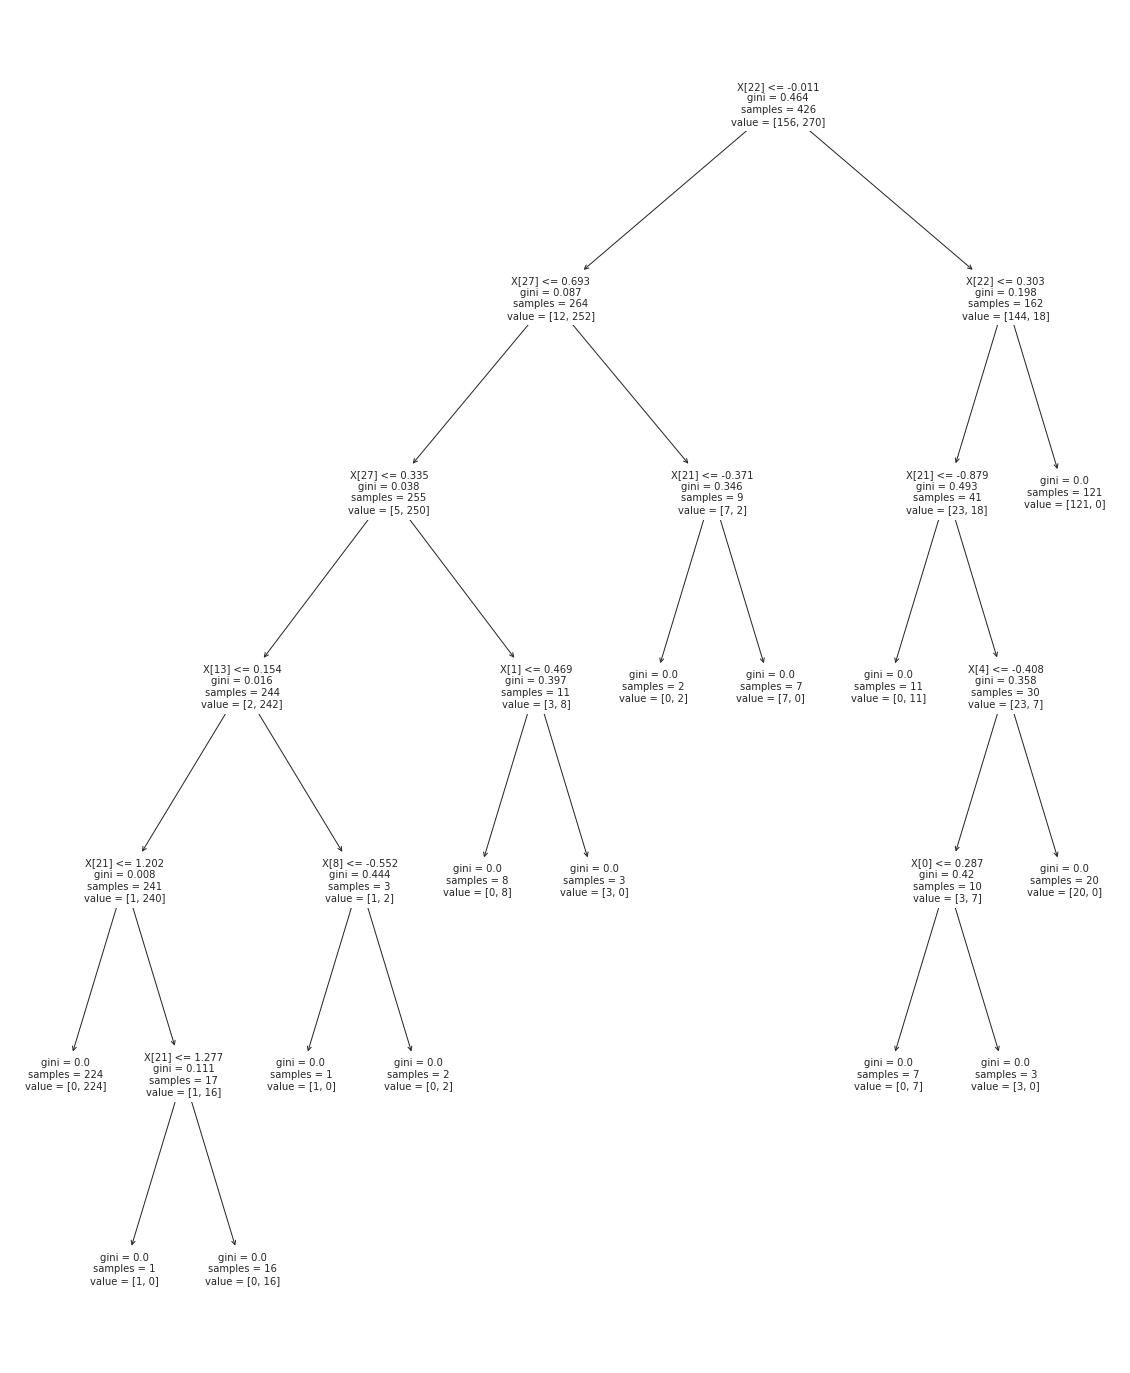

In [ ]:
from sklearn import tree
plt.figure(figsize=(20,25))
tree.plot_tree(dec_tree, fontsize=10)

#Using Radnom Forests

In [ ]:
# Importing the needed librarires for using Random Forests
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score

#Dropping some new features to test out the outcome of the random forests

In [ ]:
dropped_list1 = ['compactness_mean','concave points_mean','radius_mean','perimeter_mean','area_se','perimeter_se','concavity_se','concave points_se','radius_worst','perimeter_worst','compactness_worst','concave points_worst','texture_worst','area_worst']
X_data1 = X_data.drop(dropped_list1, axis = 1 )        # we're using X_data1, so that we won't modify X_data, in case we need to use it later
X_data1

,texture_mean,area_mean,smoothness_mean,concavity_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,smoothness_se,compactness_se,symmetry_se,fractal_dimension_se,smoothness_worst,concavity_worst,symmetry_worst,fractal_dimension_worst
0,10.38,1001.0,0.11840,0.30010,0.2419,0.07871,1.0950,0.9053,0.006399,0.04904,0.03003,0.006193,0.16220,0.7119,0.4601,0.11890
1,17.77,1326.0,0.08474,0.08690,0.1812,0.05667,0.5435,0.7339,0.005225,0.01308,0.01389,0.003532,0.12380,0.2416,0.2750,0.08902
2,21.25,1203.0,0.10960,0.19740,0.2069,0.05999,0.7456,0.7869,0.006150,0.04006,0.02250,0.004571,0.14440,0.4504,0.3613,0.08758
3,20.38,386.1,0.14250,0.24140,0.2597,0.09744,0.4956,1.1560,0.009110,0.07458,0.05963,0.009208,0.20980,0.6869,0.6638,0.17300
4,14.34,1297.0,0.10030,0.19800,0.1809,0.05883,0.7572,0.7813,0.011490,0.02461,0.01756,0.005115,0.13740,0.4000,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,22.39,1479.0,0.11100,0.24390,0.1726,0.05623,1.1760,1.2560,0.010300,0.02891,0.01114,0.004239,0.14100,0.4107,0.2060,0.07115
565,28.25,1261.0,0.09780,0.14400,0.1752,0.05533,0.7655,2.4630,0.005769,0.02423,0.01898,0.002498,0.11660,0.3215,0.2572,0.06637
566,28.08,858.1,0.08455,0.09251,0.1590,0.05648,0.4564,1.0750,0.005903,0.03731,0.01318,0.003892,0.11390,0.3403,0.2218,0.07820
567,29.33,1265.0,0.11780,0.35140,0.2397,0.07016,0.7260,1.5950,0.006522,0.06158,0.02324,0.006185,0.16500,0.9387,0.4087,0.12400


#Correlation matrix after the dropped features


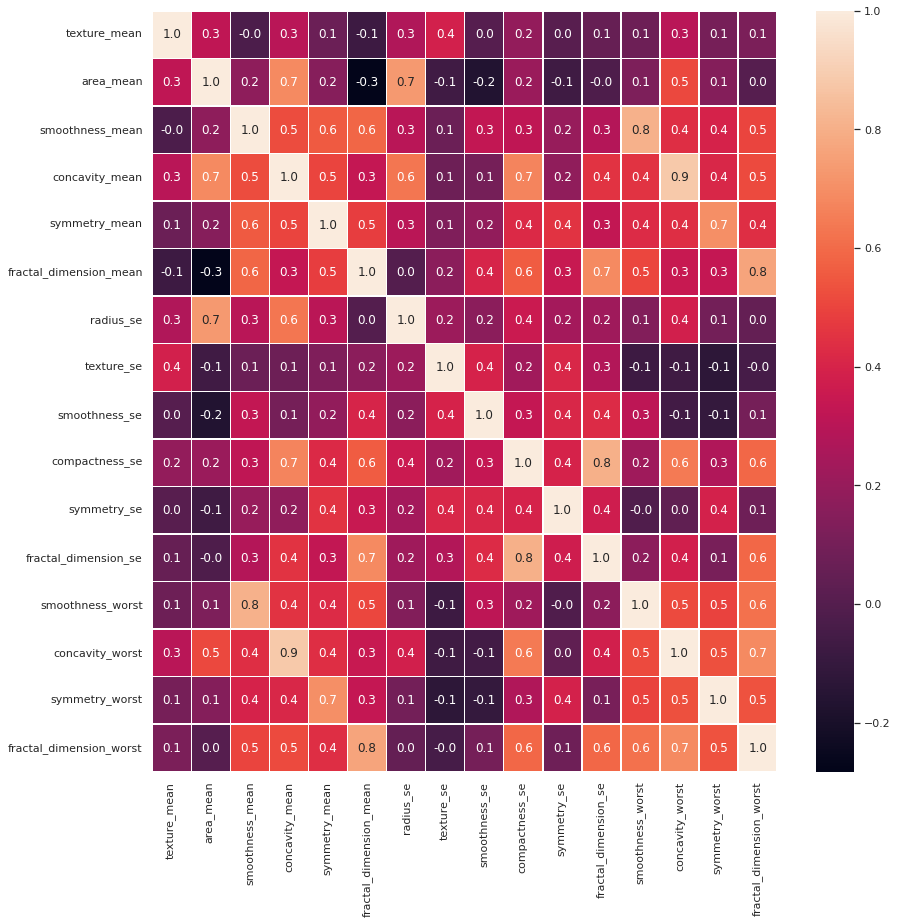

In [ ]:
#Correlation map
f,ax = plt.subplots(figsize=(14, 14))
sns.heatmap(X_data1.corr(), annot=True, linewidths=.5, fmt= '.1f',ax=ax)

#Spliting the newly dropped data

In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(X_data1, Y_data, test_size=0.25,random_state=0) # split data train 75 % and test 25 %

#Creating and evaluating the model

In [ ]:
# Using a Random Forest with n_estimators=10 (default)
rand_forest = RandomForestClassifier(n_estimators = 10,random_state=2)
rand_forest = rand_forest.fit(X_train,Y_train)

# Predicitons
X_test_pred=rand_forest.predict(X_test)
X_train_pred=rand_forest.predict(X_train)

# Checking the accuracy and the confusion matrix

Accuracy of test is:  0.9020979020979021


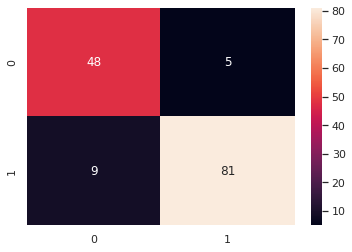

In [ ]:
# Checking the test accuracy
accuracy_test = accuracy_score(Y_test, X_test_pred)
print('Accuracy of test is: ', accuracy_test)

# Confusion matrix
cm = confusion_matrix(Y_test,rand_forest.predict(X_test))
sns.heatmap(cm, annot=True, fmt="d")

#Building a predictive model for Ranodom Forests

In [ ]:
input_data=(10.38,	1001.0,	0.11840,	0.3001,	0.2419,	0.07871,	1.0950,	0.9053,	0.006399,	0.04904,	0.03003,	0.006193,	0.1622,	0.7119,	0.4601,	0.11890) #M
#input_data=(24.54,	181.0,	0.05263,	0.00000,	0.1587,	0.05884,	0.3857,	1.4280,	0.007189,	0.00466, 0.02676,	0.002783,	0.08996,	0.0000,	0.2871,	0.07039) #B

# Change the input data to a numpy array
input_data_as_numpy_array=np.asarray(input_data)

# Reshape the numpy array as we are predicting for one data point
# beacuse the model doesn't know that we'd like to predict the value of only one feature
input_data_reshaped=input_data_as_numpy_array.reshape(1,-1)

prediction=rand_forest.predict(input_data_reshaped)
print(prediction)

# Checking if the value of the first element of the prediction list is 0 or 1
# And based on that we are writing out if the cancer is Malignant or Benign
if(prediction[0]==0):
  print('The breast cancer is Malignant')
else:
  print('The breast cancer is Bening')

[0]
The breast cancer is Malignant


/usr/local/lib/python3.7/dist-packages/sklearn/base.py:451: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  "X does not have valid feature names, but"


#Plotting the accuracy as a function of the n_estimators

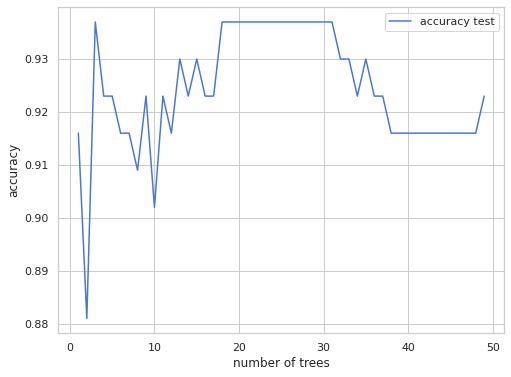

In [ ]:
num_estimators=np.arange(1,50) # creating an array with numbers from 0 to 20
accuracy_test=[]                # creating an empty array

# The whole previous algorithm is being repeated where only the n_estimators is being changed
for num in num_estimators:
  rand_forest = RandomForestClassifier(n_estimators = num,random_state=2)
  rand_forest = rand_forest.fit(X_train,Y_train)              # fitting the data

  X_test_pred=rand_forest.predict(X_test)                     # evaluating predictions

  accuracy_test.append(accuracy_score(Y_test,X_test_pred))    # storing the accuracy score in the accuracy_test array

fig = plt.figure(figsize=(8, 6))
plt.ylabel('accuracy')
plt.xlabel('number of trees')
plt.plot(num_estimators, accuracy_test,"-b", label="accuracy test")
plt.legend(loc="best")
plt.show()